In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
boston = pd.read_csv(r"C:\Users\gouth\Desktop\Goutham\Stats\DataSet\Boston_Housing Data.csv")
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


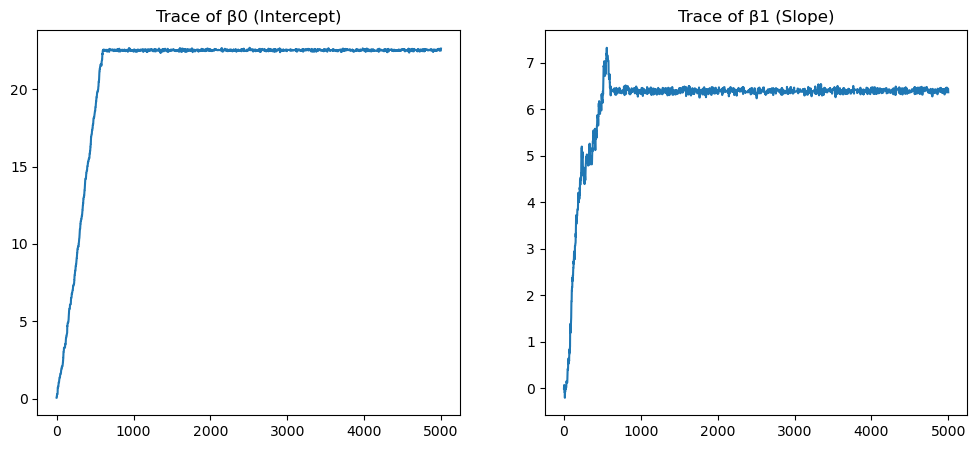

In [2]:
#Metropolis–Hastings
X = boston[['RM']]
y = boston['MEDV']
X = (X - X.mean()) / X.std()
def log_likelihood(beta, X, y, sigma=1.0):
    y_pred = beta[0] + beta[1] * X.squeeze()
    return np.sum(norm.logpdf(y, loc=y_pred, scale=sigma))
def log_prior(beta):
    return np.sum(norm.logpdf(beta, loc=0, scale=10))
def log_posterior(beta, X, y, sigma=1.0):
    return log_prior(beta) + log_likelihood(beta, X, y, sigma)
np.random.seed(42)
n_iter = 5000
beta_samples = np.zeros((n_iter, 2))
beta_current = np.array([0.0, 0.0])
for i in range(n_iter):
    beta_proposal = beta_current + np.random.normal(0, 0.1, size=2)
    log_accept_ratio = log_posterior(beta_proposal, X, y) - log_posterior(beta_current, X, y)
    if np.log(np.random.rand()) < log_accept_ratio:
        beta_current = beta_proposal
    beta_samples[i] = beta_current  # Always store current state
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(beta_samples[:,0])
plt.title("Trace of β0 (Intercept)")
plt.subplot(1,2,2)
plt.plot(beta_samples[:,1])
plt.title("Trace of β1 (Slope)")
plt.show()

Posterior mean of coefficients:
Intercept: 16.183
RM: 4.733
LSTAT: -0.562
PTRATIO: -0.883

Posterior mean of sigma^2: 27.28741411055909


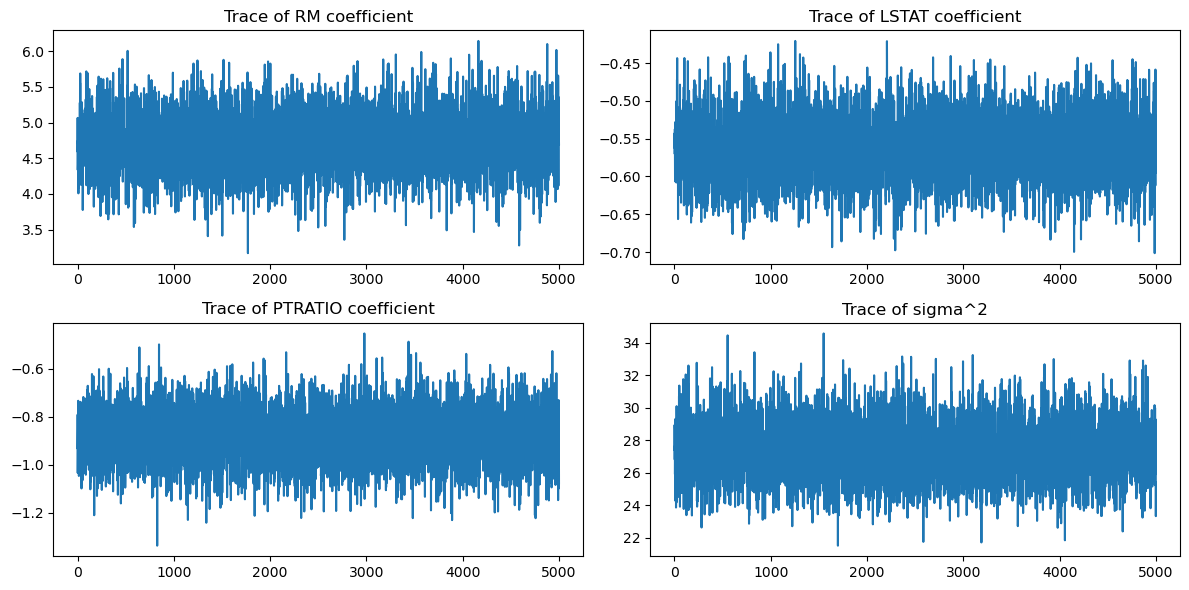

In [4]:
#Gibbs Sampler
y = boston["MEDV"].values
X = boston[["RM", "LSTAT", "PTRATIO"]].values
n, p = X.shape
X = np.column_stack((np.ones(n), X))
beta0 = np.zeros(p+1)
V0 = np.eye(p+1) * 100
alpha0 = 2
beta0_sigma = 2

beta = np.zeros(p+1)
sigma2 = 1
n_iter = 5000

beta_samples = []
sigma2_samples = []

for i in range(n_iter):
    Vn_inv = np.linalg.inv(np.linalg.inv(V0) + (X.T @ X) / sigma2)
    mn = Vn_inv @ (np.linalg.inv(V0) @ beta0 + (X.T @ y) / sigma2)
    beta = np.random.multivariate_normal(mn, Vn_inv)
    
    alpha_n = alpha0 + n/2
    resid = y - X @ beta
    beta_n = beta0_sigma + 0.5 * np.sum(resid**2)
    sigma2 = invgamma.rvs(a=alpha_n, scale=beta_n)
    
    beta_samples.append(beta)
    sigma2_samples.append(sigma2)

beta_samples = np.array(beta_samples)
sigma2_samples = np.array(sigma2_samples)
print("Posterior mean of coefficients:")
for name, val in zip(["Intercept","RM","LSTAT","PTRATIO"], beta_samples.mean(axis=0)):
    print(f"{name}: {val:.3f}")

print("\nPosterior mean of sigma^2:", np.mean(sigma2_samples))
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.plot(beta_samples[:,1])
plt.title("Trace of RM coefficient")
plt.subplot(2,2,2)
plt.plot(beta_samples[:,2])
plt.title("Trace of LSTAT coefficient")
plt.subplot(2,2,3)
plt.plot(beta_samples[:,3])
plt.title("Trace of PTRATIO coefficient")
plt.subplot(2,2,4)
plt.plot(sigma2_samples)
plt.title("Trace of sigma^2")
plt.tight_layout()
plt.show()